# Ablation-Study Analysis

Dieses Notebook vergleicht Groundtruth-Feature-Importances mit `GNNExplainer` und `Integrated Gradients`.

- **Datenquelle Explainer:** `results/rankings/*.json` (kein erneuter Batch-Lauf noetig).
- **Spearman** wird auf `gt_signed` vs. Ranking-Score berechnet.
- **Rank-Scatterplots:**
  - einmal `Integrated Gradients vs Groundtruth`
  - einmal `GNNExplainer vs Groundtruth`
  - je Plot zwei Panels (`C-Features`, `H-Features`)
  - Targets `H` und `C` jeweils zusammen im selben Panel.
- Exporte werden in `results/ablation/` geschrieben.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

try:
    from feature_visualization import get_feature_names
except ImportError:
    from notebooks.feature_visualization import get_feature_names

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

GROUNDTRUTH_PATH = PROJECT_ROOT / "results" / "groundtruth" / "feature_importance_summary.csv"
RANKINGS_DIR = PROJECT_ROOT / "results" / "rankings"
OUTPUT_DIR = PROJECT_ROOT / "results" / "ablation"
PLOTS_DIR = OUTPUT_DIR / "plots"

METHODS = ["gnnexplainer", "integrated_gradients"]
TARGETS = ["H", "C"]
FEATURE_TYPES = ["C", "H"]

ELEMENT_ONEHOT = ["H", "C", "Li", "B", "N", "O", "Na", "Mg", "Al", "Si", "P", "S", "Cl"]

UNI_BLUE = "#004e9f"
UNI_YELLOW = "#fcba00"
UNI_GREY = "#909085"
UNI_GREY_25 = "#e3e3e0"
UNI_BLACK = "#1a1a1a"

METHOD_COLORS = {
    "gnnexplainer": UNI_BLUE,
    "integrated_gradients": UNI_YELLOW,
}

METHOD_LABELS = {
    "gnnexplainer": "GNNExplainer",
    "integrated_gradients": "Integrated Gradients",
}

TARGET_COLORS = {
    "H": UNI_BLUE,
    "C": UNI_YELLOW,
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def feature_names_for(node_type: str, length: int):
    names = list(get_feature_names(node_type) or [])
    if len(names) < length:
        names.extend([f"{node_type}_extra_{i}" for i in range(len(names), length)])
    return names[:length]


def canonical_feature_name(name: str) -> str:
    value = str(name).strip()
    if value == "CN(X)":
        return "CNX"
    return value


def make_groundtruth_key(node_type: str, feature_name: str) -> str:
    if node_type in {"H", "C"} and feature_name in ELEMENT_ONEHOT:
        return f"nodetype_onehot_{node_type}"
    return f"{canonical_feature_name(feature_name)}_{node_type}"


def _safe_spearman(x, y):
    xa = np.asarray(x, dtype=float).reshape(-1)
    ya = np.asarray(y, dtype=float).reshape(-1)
    mask = np.isfinite(xa) & np.isfinite(ya)
    xa = xa[mask]
    ya = ya[mask]
    if xa.size < 2:
        return float("nan"), float("nan")
    if np.std(xa) < 1e-12 or np.std(ya) < 1e-12:
        return 0.0, 1.0
    r, p = spearmanr(xa, ya)
    if np.isnan(r):
        return 0.0, 1.0
    return float(r), float(p) if p is not None else float("nan")


def _normalize_sum1(vec):
    arr = np.asarray(vec, dtype=float).reshape(-1)
    arr = np.where(np.isfinite(arr), arr, 0.0)
    total = float(np.sum(arr))
    if total <= 1e-12:
        return np.zeros_like(arr)
    return arr / total


def _rank_desc(values):
    s = pd.Series(np.asarray(values, dtype=float))
    return s.rank(ascending=False, method="first").astype(int).to_numpy()


def _apply_uni_style(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor("#fafaf8")
    ax.figure.patch.set_facecolor("white")
    ax.grid(color=UNI_GREY_25, linewidth=0.8, linestyle="-", alpha=0.9)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=UNI_BLACK, labelsize=10)
    if title:
        ax.set_title(title, color=UNI_BLUE, fontsize=12, fontweight="bold", pad=10, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=UNI_BLACK, fontsize=11)
    if ylabel:
        ax.set_ylabel(ylabel, color=UNI_BLACK, fontsize=11)


In [3]:
def load_groundtruth_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Groundtruth CSV fehlt: {path}")

    df = pd.read_csv(path)
    required = {
        "ablation_feature_key",
        "ablation_feature_name",
        "ablation_node_type",
        "delta_mae_H",
        "delta_mae_C",
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"Groundtruth CSV hat fehlende Spalten: {missing}")

    df = df.copy()
    df = df[df["ablation_node_type"].isin(["H", "C"])].reset_index(drop=True)
    df["ablation_feature_key"] = df["ablation_feature_key"].astype(str).str.strip()

    if len(df) != 48:
        raise ValueError(f"Erwartet 48 Groundtruth-Features (H/C), gefunden: {len(df)}.")

    return df.sort_values("ablation_feature_key").reset_index(drop=True)


def load_ranking_rows(method: str, target: str, rankings_dir: Path):
    if method == "gnnexplainer":
        path = rankings_dir / f"gnn_global_ranking_{target}.json"
    elif method == "integrated_gradients":
        path = rankings_dir / f"ig_joint_ranking_{target}.json"
    else:
        raise ValueError(f"Unbekannte Methode: {method}")

    if not path.exists():
        raise FileNotFoundError(
            f"Ranking-JSON fehlt: {path}\n"
            "Bitte in notebooks/gnn4nmr.ipynb die Ranking-Export-Cells ausfuehren."
        )

    rows = json.loads(path.read_text())
    if not isinstance(rows, list):
        raise TypeError(f"Ranking-Datei hat unerwarteten Typ: {path}")
    return path, rows


def _row_node_type(row: dict):
    nt = row.get("node_type")
    if nt in {"H", "C"}:
        return nt
    fk = str(row.get("feature_key", ""))
    if ":" in fk:
        guess = fk.split(":", 1)[0]
        if guess in {"H", "C"}:
            return guess
    return None


def _row_feature_name(row: dict):
    name = row.get("feature_name")
    if name:
        return str(name)
    fk = str(row.get("feature_key", ""))
    if ":" in fk:
        return fk.split(":", 1)[1]
    return None


def rows_to_score_map(rows: list, method: str):
    score_map = {}
    onehot_raw_sum = {"H": 0.0, "C": 0.0}

    for row in rows:
        if not isinstance(row, dict):
            continue

        node_type = _row_node_type(row)
        if node_type not in {"H", "C"}:
            continue

        feat_name = _row_feature_name(row)
        if not feat_name:
            continue

        if method == "gnnexplainer":
            value = row.get("value", row.get("importance", 0.0))
        else:
            value = row.get("score", 0.0)

        try:
            score = float(value)
        except (TypeError, ValueError):
            continue
        if not np.isfinite(score):
            continue

        key = make_groundtruth_key(node_type, feat_name)
        score_map[key] = float(score_map.get(key, 0.0) + score)

        if feat_name in ELEMENT_ONEHOT and node_type in onehot_raw_sum:
            onehot_raw_sum[node_type] += score

    return score_map, onehot_raw_sum


In [4]:
def build_aligned_table(gt_df: pd.DataFrame, target: str, method: str, score_map: dict) -> pd.DataFrame:
    target_col = f"delta_mae_{target}"
    if target_col not in gt_df.columns:
        raise ValueError(f"Groundtruth-Spalte fehlt: {target_col}")

    out = gt_df[["ablation_feature_key", "ablation_feature_name", "ablation_node_type", target_col]].copy()
    out = out.rename(
        columns={
            "ablation_feature_key": "feature_key",
            "ablation_feature_name": "feature_name",
            "ablation_node_type": "feature_node_type",
            target_col: "gt_signed",
        }
    )

    out["method"] = method
    out["target"] = target
    out["explainer_score"] = out["feature_key"].map(score_map).fillna(0.0)

    out["gt_clipped"] = out["gt_signed"].clip(lower=0.0)
    out["explainer_abs"] = out["explainer_score"].abs()

    out["gt_norm"] = _normalize_sum1(out["gt_clipped"].to_numpy())
    out["explainer_norm"] = _normalize_sum1(out["explainer_abs"].to_numpy())
    out["mae_component"] = (out["gt_norm"] - out["explainer_norm"]).abs()

    return out.sort_values("feature_key").reset_index(drop=True)


def compute_metrics(aligned_df: pd.DataFrame, ranking_path: Path) -> dict:
    r, p = _safe_spearman(aligned_df["gt_signed"], aligned_df["explainer_score"])
    mae = float(np.mean(aligned_df["mae_component"].to_numpy(dtype=float)))
    return {
        "method": str(aligned_df["method"].iloc[0]),
        "target": str(aligned_df["target"].iloc[0]),
        "n_features": int(len(aligned_df)),
        "spearman_r": float(r),
        "spearman_p": float(p),
        "mae_clipped_sum1": float(mae),
        "groundtruth_clipped": True,
        "ranking_json": str(ranking_path),
    }


def build_rank_scatter_dataframe_vs_groundtruth(aligned_by_method_target: dict, method: str) -> pd.DataFrame:
    rows = []
    for target in TARGETS:
        df = aligned_by_method_target[(method, target)].copy()
        if df.empty:
            continue

        df = df[["feature_key", "feature_node_type", "gt_signed", "explainer_score"]].copy()
        df = df.sort_values("feature_key").reset_index(drop=True)
        df["gt_rank"] = _rank_desc(df["gt_signed"].to_numpy(dtype=float))
        df["explainer_rank"] = _rank_desc(df["explainer_score"].to_numpy(dtype=float))
        df["target"] = target
        rows.append(df)

    if not rows:
        return pd.DataFrame(
            columns=["feature_key", "feature_node_type", "target", "gt_signed", "explainer_score", "gt_rank", "explainer_rank"]
        )

    out = pd.concat(rows, ignore_index=True)
    return out[["feature_key", "feature_node_type", "target", "gt_signed", "explainer_score", "gt_rank", "explainer_rank"]]


def plot_rank_scatter_vs_groundtruth(rank_df: pd.DataFrame, method: str, out_file: Path, pdf_file: Path = None):
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.2), dpi=120)

    for ax, feat_type in zip(axes, FEATURE_TYPES):
        panel = rank_df[rank_df["feature_node_type"] == feat_type].copy()

        if panel.empty:
            _apply_uni_style(ax, title=f"{feat_type}-Features", xlabel="Groundtruth rank", ylabel=f"{METHOD_LABELS[method]} rank")
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", color=UNI_BLACK)
            continue

        lim = int(max(panel["gt_rank"].max(), panel["explainer_rank"].max(), 1)) + 1
        ax.plot([1, lim], [1, lim], color=UNI_GREY, linestyle="--", linewidth=1.1, zorder=2)

        for target in TARGETS:
            subset = panel[panel["target"] == target]
            if subset.empty:
                continue
            r, _ = _safe_spearman(subset["gt_rank"], subset["explainer_rank"])
            r_txt = f"{r:.3f}" if np.isfinite(r) else "n/a"
            label = f"Target {target} (r={r_txt})"

            ax.scatter(
                subset["gt_rank"],
                subset["explainer_rank"],
                s=28,
                alpha=0.9,
                color=TARGET_COLORS[target],
                edgecolors="white",
                linewidths=0.6,
                label=label,
                zorder=3,
            )

        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        _apply_uni_style(
            ax,
            title=f"{feat_type}-Features",
            xlabel="Groundtruth rank",
            ylabel=f"{METHOD_LABELS[method]} rank",
        )
        ax.legend(fontsize=8.5, frameon=True, framealpha=0.95, edgecolor=UNI_GREY_25, loc="upper left")

    fig.suptitle(f"{METHOD_LABELS[method]} vs Groundtruth (Rank Scatter)", fontsize=13, color=UNI_BLUE, fontweight="bold")
    plt.tight_layout()
    fig.savefig(out_file, bbox_inches="tight")
    if pdf_file is not None:
        fig.savefig(pdf_file, bbox_inches="tight")
    plt.show()


In [5]:
def run_ablation_analysis(project_root: Path = PROJECT_ROOT):
    gt_df = load_groundtruth_table(GROUNDTRUTH_PATH)
    print(f"[INFO] Groundtruth geladen: {GROUNDTRUTH_PATH} ({len(gt_df)} Features)")

    metric_rows = []
    validation_rows = []
    aligned_by_method_target = {}

    for method in METHODS:
        for target in TARGETS:
            ranking_path, rows = load_ranking_rows(method, target, RANKINGS_DIR)
            print(f"[INFO] {METHOD_LABELS[method]} Target={target}: {ranking_path.name}")

            score_map, onehot_raw_sum = rows_to_score_map(rows, method)
            aligned_df = build_aligned_table(gt_df, target=target, method=method, score_map=score_map)
            aligned_by_method_target[(method, target)] = aligned_df.copy()

            if len(aligned_df) != 48:
                raise AssertionError(f"Alignment hat {len(aligned_df)} Zeilen statt 48.")

            expected_keys = set(gt_df["ablation_feature_key"].astype(str))
            got_keys = set(aligned_df["feature_key"].astype(str))
            missing = sorted(expected_keys - got_keys)
            if missing:
                raise AssertionError(f"Pflicht-Keys fehlen im Alignment: {missing}")

            for nt in ["H", "C"]:
                agg_key = f"nodetype_onehot_{nt}"
                agg_val = float(score_map.get(agg_key, 0.0))
                raw_val = float(onehot_raw_sum.get(nt, 0.0))
                if not math.isclose(agg_val, raw_val, rel_tol=1e-9, abs_tol=1e-9):
                    raise AssertionError(
                        f"Onehot-Check fehlgeschlagen ({method}, {target}, {nt}): "
                        f"aggregiert={agg_val}, raw_sum={raw_val}"
                    )

            clipped_expected = np.clip(aligned_df["gt_signed"].to_numpy(dtype=float), 0.0, None)
            clipped_actual = aligned_df["gt_clipped"].to_numpy(dtype=float)
            if not np.allclose(clipped_actual, clipped_expected):
                raise AssertionError(f"Clip-Check fehlgeschlagen ({method}, {target}).")

            r1, p1 = _safe_spearman(aligned_df["gt_signed"], aligned_df["explainer_score"])
            r2, p2 = _safe_spearman(aligned_df["gt_signed"].to_numpy(), aligned_df["explainer_score"].to_numpy())
            if not (math.isclose(r1, r2, rel_tol=1e-12, abs_tol=1e-12) and (
                (np.isnan(p1) and np.isnan(p2)) or math.isclose(p1, p2, rel_tol=1e-12, abs_tol=1e-12)
            )):
                raise AssertionError(f"Spearman-Check fehlgeschlagen ({method}, {target}).")

            mae_value = float(np.mean(aligned_df["mae_component"].to_numpy(dtype=float)))
            if (not np.isfinite(mae_value)) or mae_value < 0.0:
                raise AssertionError(f"MAE-Check fehlgeschlagen ({method}, {target}): {mae_value}")

            aligned_path = OUTPUT_DIR / f"aligned_{method}_{target}.csv"
            aligned_df.to_csv(aligned_path, index=False)

            row = compute_metrics(aligned_df, ranking_path=ranking_path)
            row["aligned_csv"] = str(aligned_path)
            metric_rows.append(row)

            validation_rows.append(
                {
                    "method": method,
                    "target": target,
                    "rows": int(len(aligned_df)),
                    "onehot_H_ok": True,
                    "onehot_C_ok": True,
                    "clip_ok": True,
                    "spearman_check_ok": True,
                    "mae_ok": True,
                }
            )

    # Neue Rank-Scatterplots: je Methode gegen Groundtruth.
    rank_artifacts = {}
    for method in METHODS:
        rank_df = build_rank_scatter_dataframe_vs_groundtruth(aligned_by_method_target, method)
        if rank_df.empty:
            raise AssertionError(f"Rank-Scatter Daten sind leer fuer Methode {method}.")

        for feat_type in FEATURE_TYPES:
            for target in TARGETS:
                n = int(((rank_df["feature_node_type"] == feat_type) & (rank_df["target"] == target)).sum())
                if n <= 0:
                    raise AssertionError(
                        f"Keine Rank-Daten fuer Methode={method}, Panel={feat_type}, Target={target}."
                    )

        points_path = OUTPUT_DIR / f"rank_scatter_points_{method}_vs_groundtruth.csv"
        rank_df.to_csv(points_path, index=False)

        plot_svg_path = PLOTS_DIR / f"rank_scatter_{method}_vs_groundtruth_by_feature_type.svg"
        plot_pdf_path = plot_svg_path.with_suffix(".pdf")
        plot_rank_scatter_vs_groundtruth(rank_df, method=method, out_file=plot_svg_path, pdf_file=plot_pdf_path)

        rank_artifacts[method] = {
            "points_csv": str(points_path),
            "plot_svg": str(plot_svg_path),
            "plot_pdf": str(plot_pdf_path),
        }

    metrics_df = pd.DataFrame(metric_rows).sort_values(["method", "target"]).reset_index(drop=True)
    metrics_df["rank_scatter_plot_svg"] = metrics_df["method"].map(lambda m: rank_artifacts[m]["plot_svg"])
    metrics_df["rank_scatter_plot_pdf"] = metrics_df["method"].map(lambda m: rank_artifacts[m]["plot_pdf"])
    metrics_df["rank_scatter_points_csv"] = metrics_df["method"].map(lambda m: rank_artifacts[m]["points_csv"])

    metrics_path = OUTPUT_DIR / "metrics_groundtruth_vs_explainers.csv"
    metrics_df.to_csv(metrics_path, index=False)

    validation_df = pd.DataFrame(validation_rows).sort_values(["method", "target"]).reset_index(drop=True)
    validation_path = OUTPUT_DIR / "validation_checks.csv"
    validation_df.to_csv(validation_path, index=False)

    print(f"[INFO] Metrics gespeichert: {metrics_path}")
    print(f"[INFO] Validation gespeichert: {validation_path}")
    for method in METHODS:
        print(f"[INFO] {METHOD_LABELS[method]} Rank-Scatter CSV: {rank_artifacts[method]['points_csv']}")
        print(f"[INFO] {METHOD_LABELS[method]} Rank-Scatter Plot (SVG): {rank_artifacts[method]['plot_svg']}")
        print(f"[INFO] {METHOD_LABELS[method]} Rank-Scatter Plot (PDF): {rank_artifacts[method]['plot_pdf']}")

    display(metrics_df)
    display(validation_df)

    return metrics_df, validation_df


[INFO] Groundtruth geladen: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\groundtruth\feature_importance_summary.csv (48 Features)
[INFO] GNNExplainer Target=H: gnn_global_ranking_H.json
[INFO] GNNExplainer Target=C: gnn_global_ranking_C.json
[INFO] Integrated Gradients Target=H: ig_joint_ranking_H.json
[INFO] Integrated Gradients Target=C: ig_joint_ranking_C.json


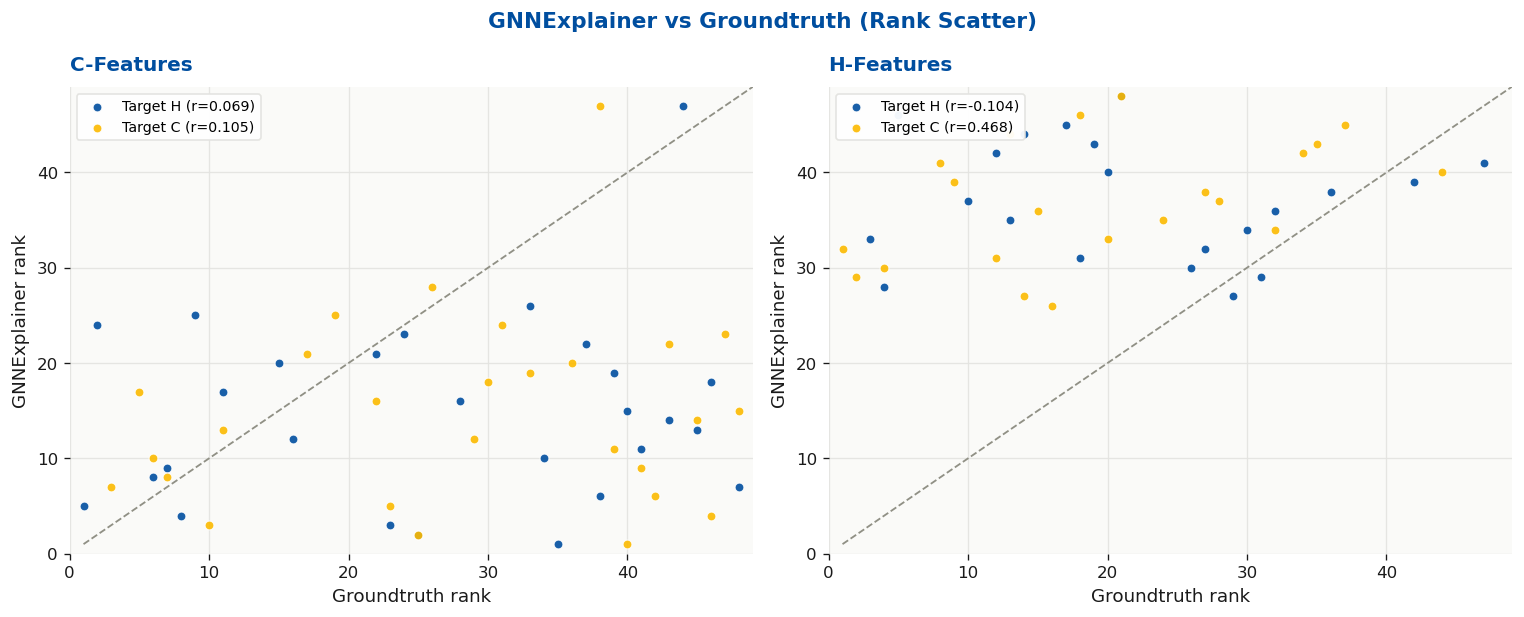

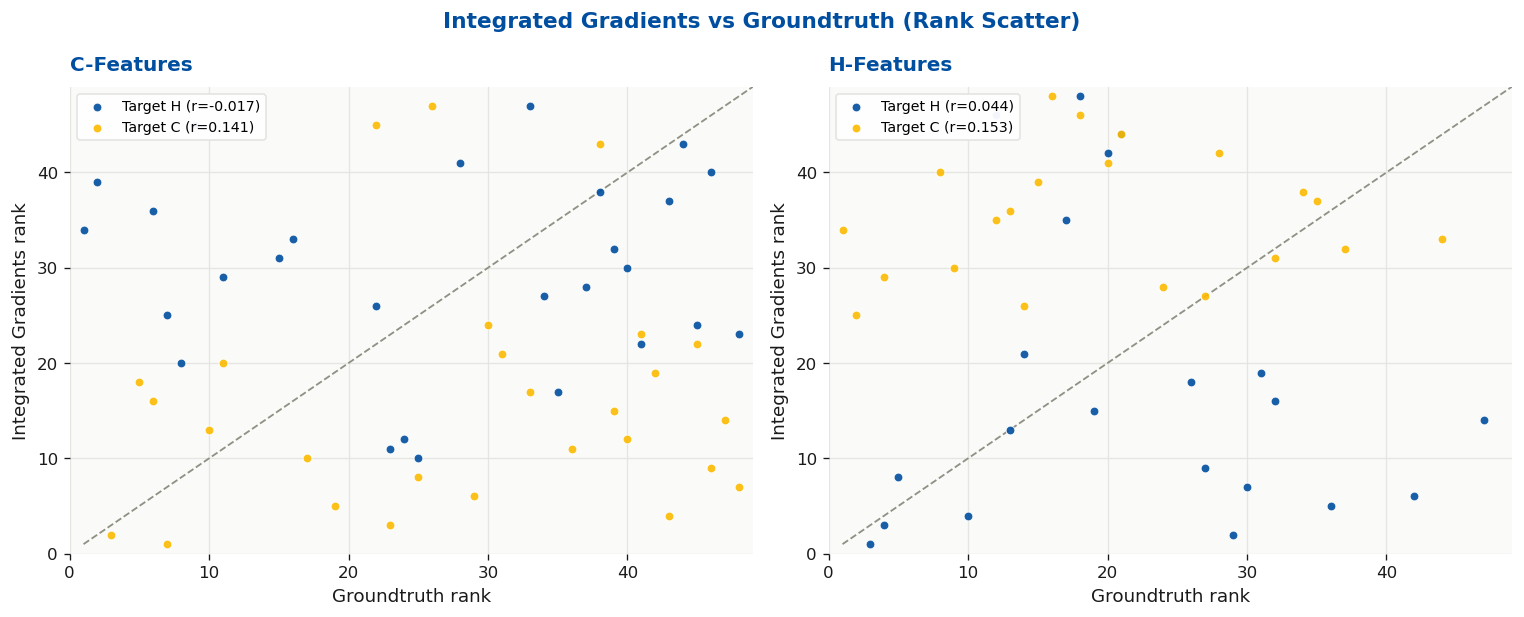

[INFO] Metrics gespeichert: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\metrics_groundtruth_vs_explainers.csv
[INFO] Validation gespeichert: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\validation_checks.csv
[INFO] GNNExplainer Rank-Scatter CSV: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\rank_scatter_points_gnnexplainer_vs_groundtruth.csv
[INFO] GNNExplainer Rank-Scatter Plot (SVG): c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\plots\rank_scatter_gnnexplainer_vs_groundtruth_by_feature_type.svg
[INFO] GNNExplainer Rank-Scatter Plot (PDF): c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\plots\rank_scatter_gnnexplainer_vs_groundtruth_by_feature_type.pdf
[INFO] Integrated Gradients Rank-Scatter CSV: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\rank_scatter_points_integrated_gradients_vs_groundtruth.csv
[INFO] Integrated Gradients Rank-Scatter Plot (SVG): c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablation\plots\rank_scatter_integrated_gradients_vs_groundtruth_by_feature_type.s

,method,target,n_features,spearman_r,spearman_p,mae_clipped_sum1,groundtruth_clipped,ranking_json,aligned_csv,rank_scatter_plot_svg,rank_scatter_plot_pdf,rank_scatter_points_csv
0,gnnexplainer,C,48,-0.098190,0.506720,0.033388,True,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ranking...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...
1,gnnexplainer,H,48,-0.094282,0.523860,0.012811,True,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ranking...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...
2,integrated_gradients,C,48,-0.128615,0.383640,0.030776,True,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ranking...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...
3,integrated_gradients,H,48,0.033159,0.822959,0.021053,True,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ranking...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...,c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\ablatio...


,method,target,rows,onehot_H_ok,onehot_C_ok,clip_ok,spearman_check_ok,mae_ok
0,gnnexplainer,C,48,True,True,True,True,True
1,gnnexplainer,H,48,True,True,True,True,True
2,integrated_gradients,C,48,True,True,True,True,True
3,integrated_gradients,H,48,True,True,True,True,True


In [6]:
# Ausfuehren
metrics_df, validation_df = run_ablation_analysis(PROJECT_ROOT)
